# Employee Salary Prediction

This project uses Python and Machine Learning to predict employee salary based on years of experience.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error , r2_score


## 2. Creating the Dataset

The dataset contains information about employee age, years of experience, working hours, and salary.

In [2]:
data = {
    "Age":[22,25,28,30,32,35,38,40,42,45,24,27,29,31,34,36,39,41,43,50],
    
    "Experience":[1,2,4,5,7,9,12,15,17,20,2,3,5,6,8,10,13,16,18,25],
    
    "Hours":[35,40,42,45,40,45,50,48,45,55,38,40,42,44,46,45,50,48,46,100],
    
    "Salary":[25000,30000,35000,40000,45000,52000,60000,68000,72000,85000,28000,32000,37000,42000,48000,55000,63000,70000,76000,250000]
}

df=pd.DataFrame(data)

df

,Age,Experience,Hours,Salary
0,22,1,35,25000
1,25,2,40,30000
2,28,4,42,35000
3,30,5,45,40000
4,32,7,40,45000
5,35,9,45,52000
6,38,12,50,60000
7,40,15,48,68000
8,42,17,45,72000
9,45,20,55,85000


In [3]:
df.to_csv("employee_salary.csv", index=False)

print("CSV file is created!!")

CSV file is created!!


## 3. Exploring the Dataset

Before cleaning the data, we inspect its size, column names, and data types to understand the dataset.

In [4]:
df.shape

(20, 4)

In [5]:
df.columns

Index(['Age', 'Experience', 'Hours', 'Salary'], dtype='str')

In [6]:
df.dtypes

Age           int64
Experience    int64
Hours         int64
Salary        int64
dtype: object

In [7]:
df.describe()

,Age,Experience,Hours,Salary
count,20.000000,20.000000,20.000000,20.000000
mean,34.550000,9.900000,47.200000,60650.000000
std,7.646637,6.827961,13.260944,47880.635576
min,22.000000,1.000000,35.000000,25000.000000
25%,28.750000,4.750000,41.500000,36500.000000
50%,34.500000,8.500000,45.000000,50000.000000
75%,40.250000,15.250000,48.000000,68500.000000
max,50.000000,25.000000,100.000000,250000.000000


## 4. Handling Missing Values

Missing values are identified and replaced using the median value of each column.

In [8]:
df.isnull().sum()

Age           0
Experience    0
Hours         0
Salary        0
dtype: int64

In [9]:

df.loc[3,"Age"]=np.nan
df.loc[7,"Experience"]=np.nan
df.loc[12,"Hours"]=np.nan

In [10]:
df

,Age,Experience,Hours,Salary
0,22.0,1.0,35.0,25000
1,25.0,2.0,40.0,30000
2,28.0,4.0,42.0,35000
3,NaN,5.0,45.0,40000
4,32.0,7.0,40.0,45000
5,35.0,9.0,45.0,52000
6,38.0,12.0,50.0,60000
7,40.0,NaN,48.0,68000
8,42.0,17.0,45.0,72000
9,45.0,20.0,55.0,85000


In [11]:
df["Age"]=df["Age"].fillna(df["Age"].median())

df["Experience"]=df["Experience"].fillna(df["Experience"].median())

df["Hours"]=df["Hours"].fillna(df["Hours"].median())


In [12]:
df.isnull().sum()

Age           0
Experience    0
Hours         0
Salary        0
dtype: int64

## 5. Handling Outliers

Boxplots are used to identify unusual values in the dataset. Extreme values are then removed using defined thresholds for working hours and salary.

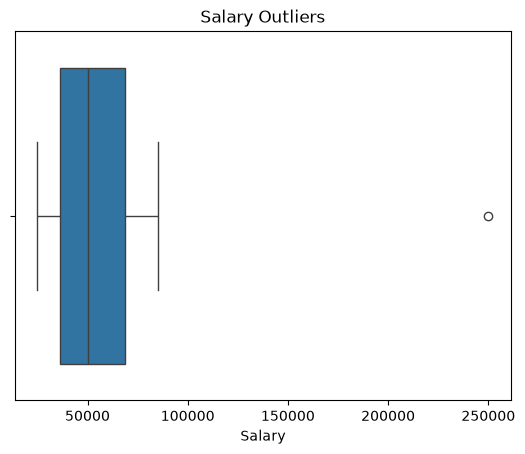

In [13]:
sns.boxplot(x=df["Salary"])

plt.title("Salary Outliers")
plt.show()

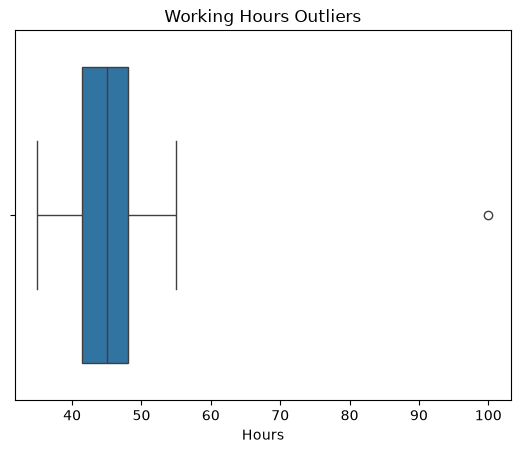

In [14]:
sns.boxplot(x=df["Hours"])

plt.title("Working Hours Outliers")
plt.show()

## 6. Data Visualization

Visualizations are used to understand the relationship between employee experience and salary, and to examine the distribution of salaries.

In [15]:
df = df[df["Hours"] < 80]
df = df[df["Salary"] < 150000]

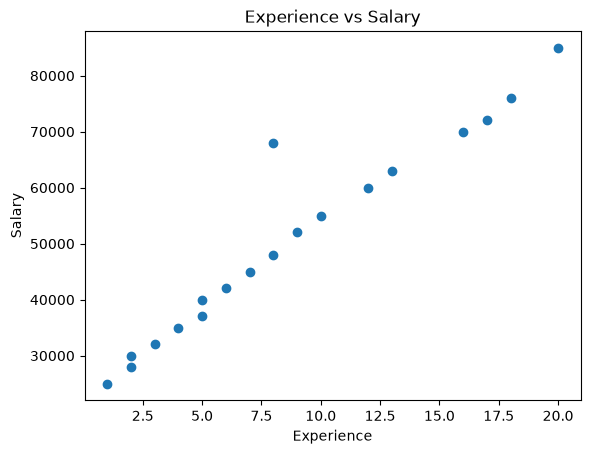

In [16]:
plt.scatter(df["Experience"], df["Salary"])

plt.xlabel("Experience")
plt.ylabel("Salary")

plt.title("Experience vs Salary")

plt.show()

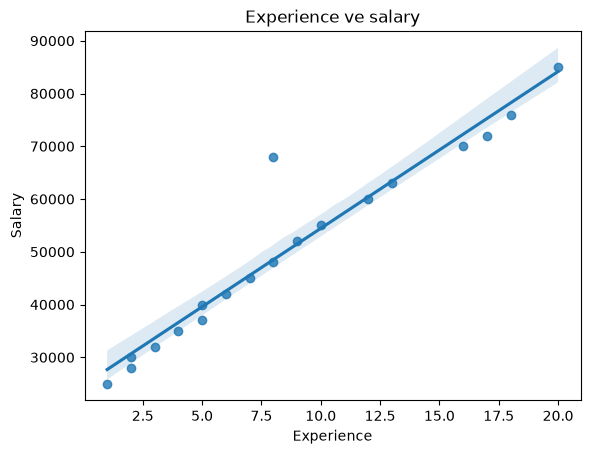

In [17]:
sns.regplot(
    x="Experience",
    y="Salary",
    data=df
)

plt.title("Experience ve salary")

plt.show()

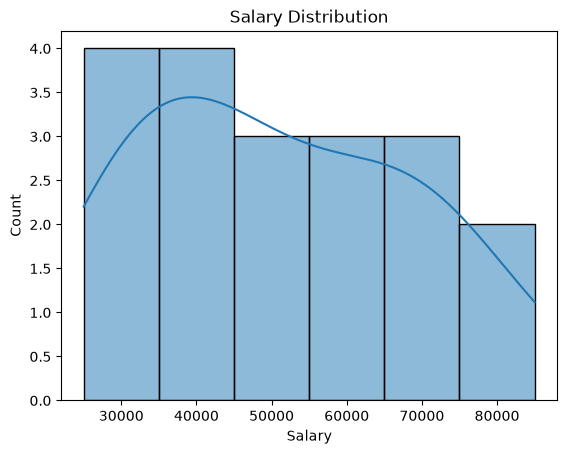

In [18]:
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

## 7. Preparing Data for Machine Learning

The Experience column is used as the input feature (X), while Salary is used as the target variable (y).

In [19]:
x = df[["Experience"]]
y = df["Salary"]

## 8. Splitting the Data

The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## 9. Training the Linear Regression Model

A Linear Regression model is trained using the training data. The model learns the relationship between years of experience and salary.

In [21]:
model = LinearRegression()

In [22]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2881.48]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.593e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 10. Making Predictions

The trained model is used to predict salaries for the test dataset.

In [23]:
y_pred = model.predict(x_test)

In [24]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results

,Actual,Predicted
0,25000,28807.911298
5,52000,51859.754270
11,32000,34570.872041
1,30000,31689.391669


## 11. Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), which measures the average difference between the actual and predicted salary values.

In [25]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:",mae)

MAE: 2052.105184297274


## 12. Predicting Salary for a New Employee

The trained model is used to predict the salary of a new employee based on 10 years of experience.

In [26]:
new_employee = pd.DataFrame({
    "Experience": [10]
})

prediction = model.predict(new_employee)

print("Predicted Salary:", prediction[0])

Predicted Salary: 54741.23464189392
